In [6]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
from temporal_analysis import run_temporal_analysis


Carregando dados e modelo...
Extraindo embeddings...
Total de sequências: 11096
Total de espécies: 13

=== ANÁLISE DE CLUSTERS ===
K=2: Silhouette Score = 0.3937
K=3: Silhouette Score = 0.4972
K=4: Silhouette Score = 0.5641
K=5: Silhouette Score = 0.6282
K=6: Silhouette Score = 0.6852
K=7: Silhouette Score = 0.7393
K=8: Silhouette Score = 0.7703
K=9: Silhouette Score = 0.8064
K=10: Silhouette Score = 0.8476


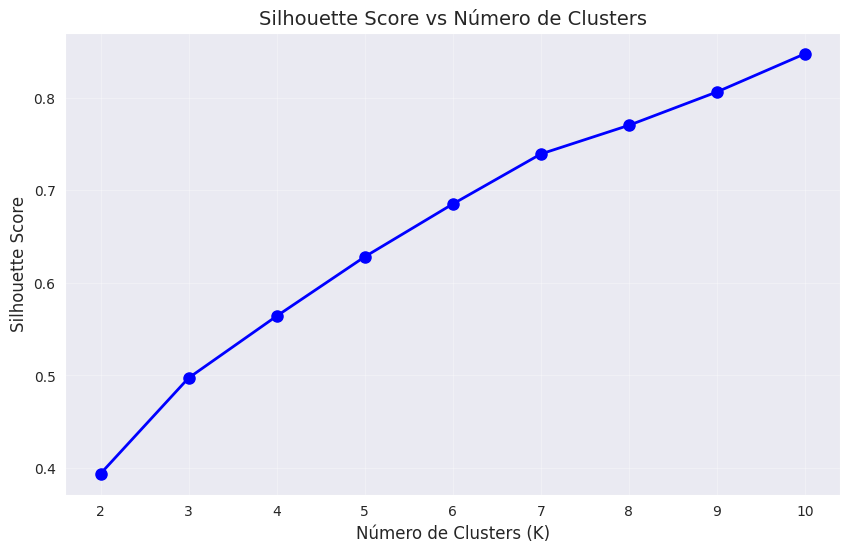


Número ótimo de clusters: 10


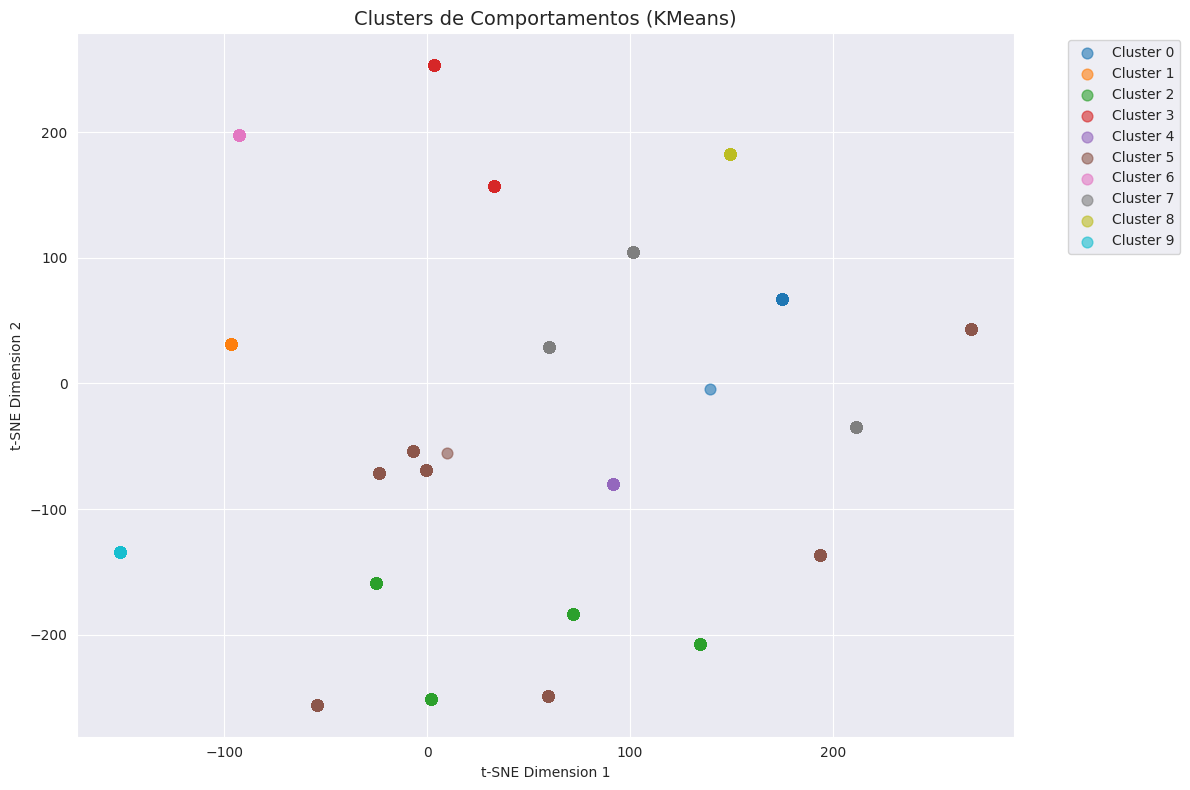


=== Composição dos Clusters ===

Cluster 0:
  - aix: 169 sequências
  - eudocinus: 120 sequências
  - palatea: 107 sequências
  - ardea_alba: 87 sequências
  - vultur: 60 sequências
  - coragyps_atratus: 43 sequências
  - sarcorhamphus: 32 sequências
  - trigonoceps: 28 sequências
  - harpya: 25 sequências
  - buteo_albicaudatus: 17 sequências
  - buteogallus: 17 sequências
  - milvago_chimachima: 16 sequências
  - gypohierax: 8 sequências

Cluster 1:
  - aix: 607 sequências
  - palatea: 577 sequências
  - eudocinus: 468 sequências
  - sarcorhamphus: 337 sequências
  - ardea_alba: 259 sequências
  - vultur: 250 sequências
  - coragyps_atratus: 241 sequências
  - gypohierax: 235 sequências
  - harpya: 224 sequências
  - buteogallus: 205 sequências
  - trigonoceps: 202 sequências
  - buteo_albicaudatus: 191 sequências
  - milvago_chimachima: 166 sequências

Cluster 2:
  - eudocinus: 212 sequências
  - palatea: 196 sequências
  - aix: 170 sequências
  - trigonoceps: 95 sequências
  - sar

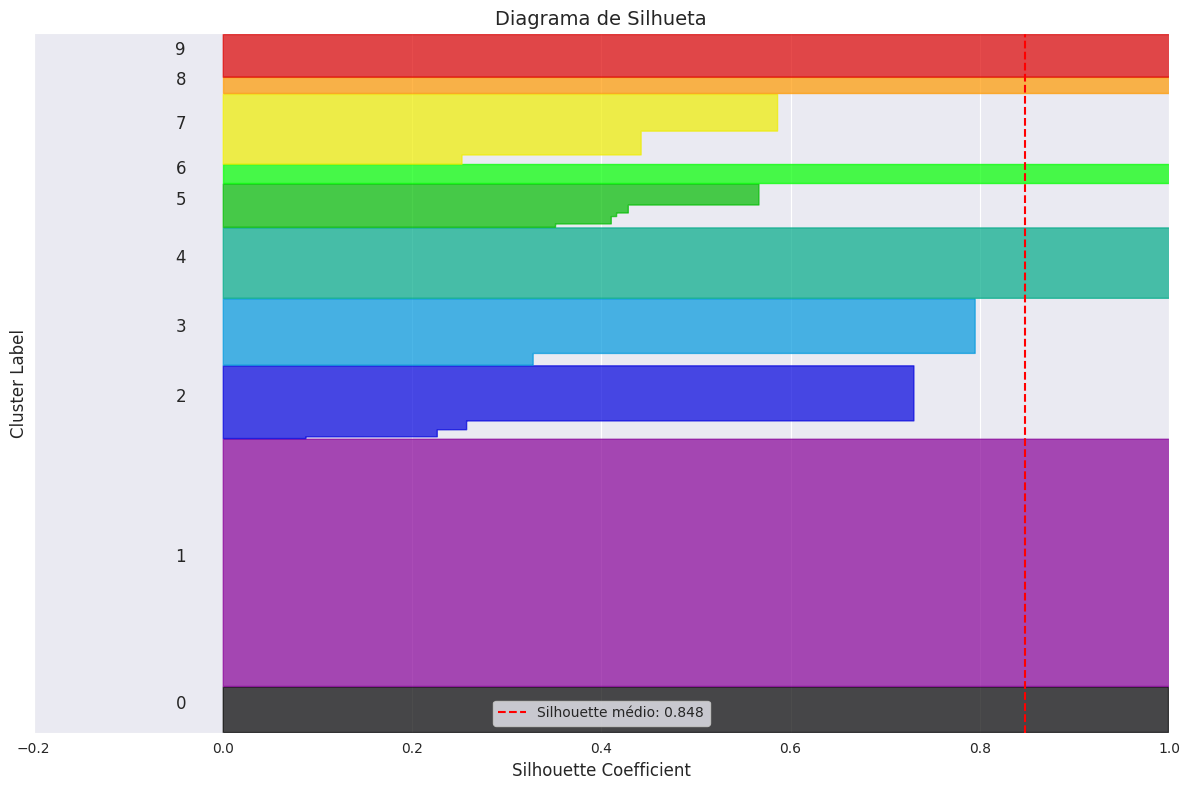


=== COMPARAÇÃO ENTRE ESPÉCIES ===


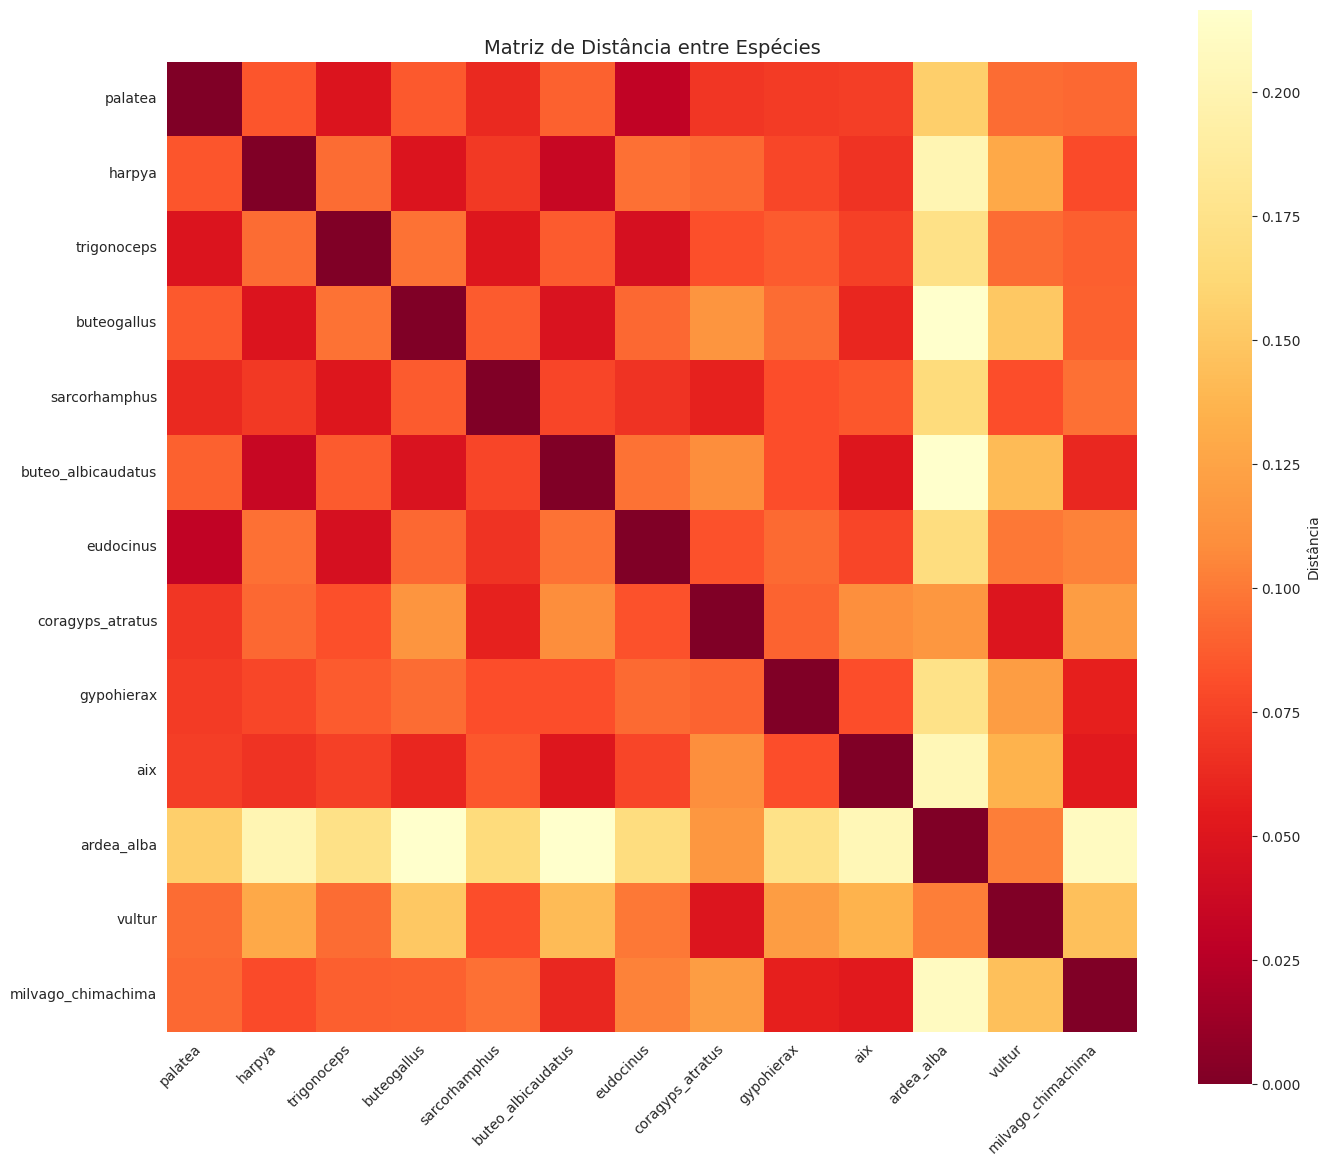

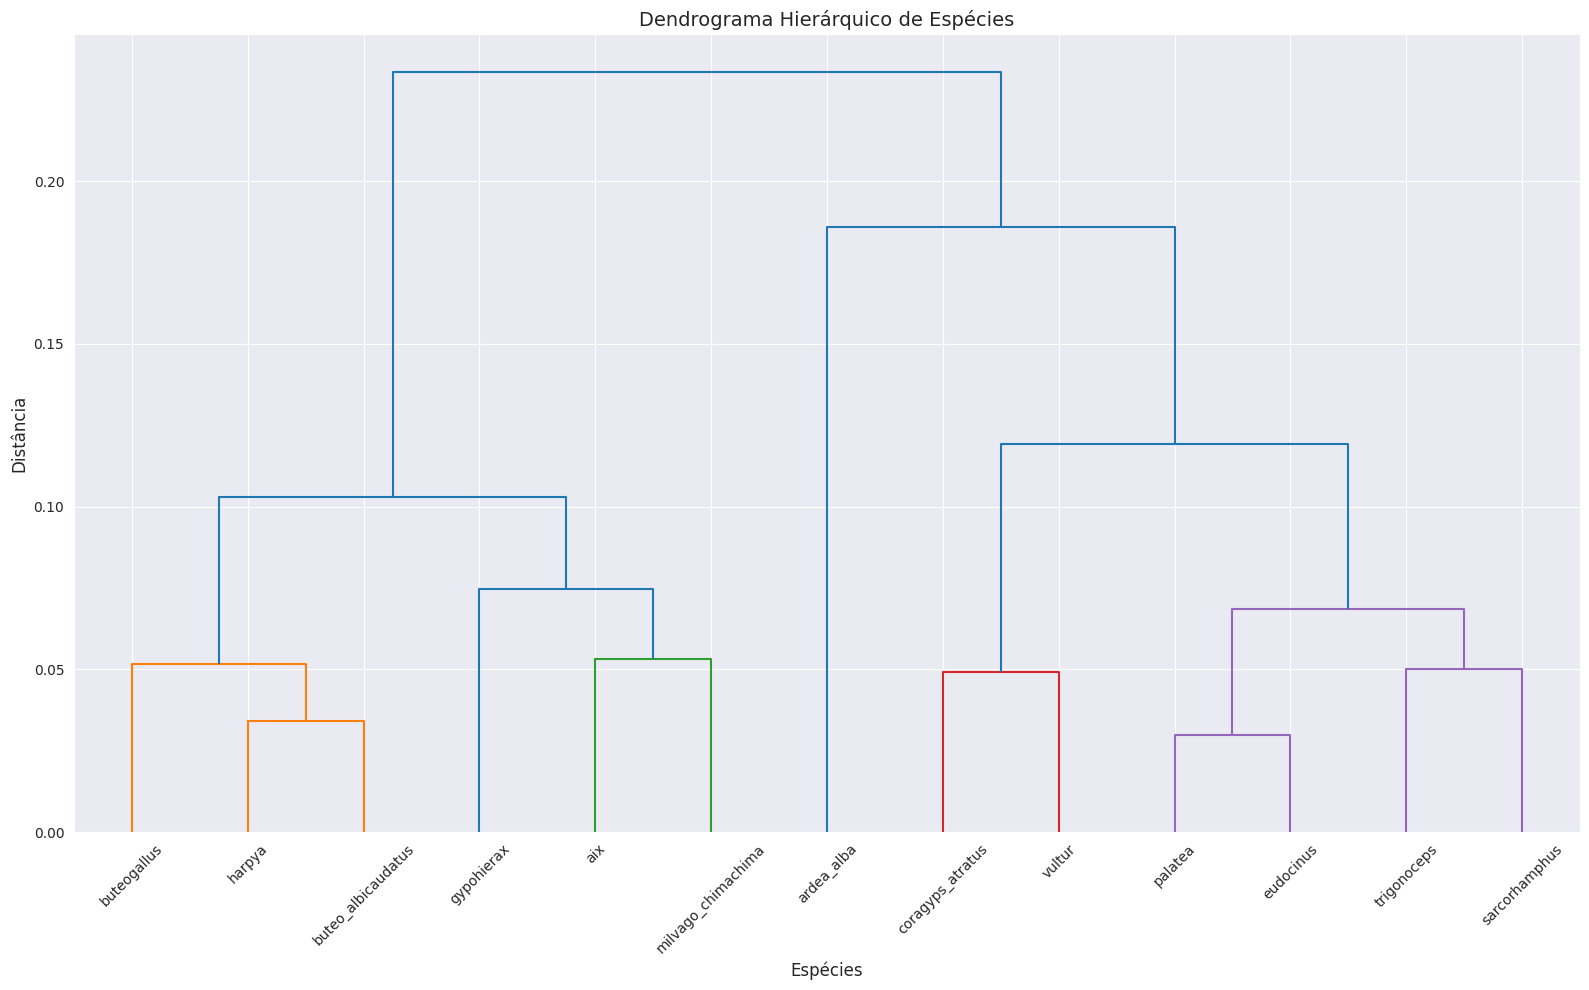


=== Top 10 Pares Mais Similares ===
palatea (N/A) ↔ eudocinus (N/A): 0.0299
harpya (N/A) ↔ buteo_albicaudatus (N/A): 0.0343
trigonoceps (N/A) ↔ eudocinus (N/A): 0.0447
buteogallus (N/A) ↔ buteo_albicaudatus (N/A): 0.0473
harpya (N/A) ↔ buteogallus (N/A): 0.0486
palatea (N/A) ↔ trigonoceps (N/A): 0.0490
coragyps_atratus (N/A) ↔ vultur (N/A): 0.0493
trigonoceps (N/A) ↔ sarcorhamphus (N/A): 0.0502
buteo_albicaudatus (N/A) ↔ aix (N/A): 0.0504
aix (N/A) ↔ milvago_chimachima (N/A): 0.0532

=== Top 10 Pares Mais Dissimilares ===
palatea (N/A) ↔ ardea_alba (N/A): 0.1555
sarcorhamphus (N/A) ↔ ardea_alba (N/A): 0.1666
eudocinus (N/A) ↔ ardea_alba (N/A): 0.1675
trigonoceps (N/A) ↔ ardea_alba (N/A): 0.1727
gypohierax (N/A) ↔ ardea_alba (N/A): 0.1736
harpya (N/A) ↔ ardea_alba (N/A): 0.2012
aix (N/A) ↔ ardea_alba (N/A): 0.2036
ardea_alba (N/A) ↔ milvago_chimachima (N/A): 0.2094
buteogallus (N/A) ↔ ardea_alba (N/A): 0.2161
buteo_albicaudatus (N/A) ↔ ardea_alba (N/A): 0.2165

=== ANÁLISE CONCLUÍDA ==

NameError: name 'processor' is not defined

In [7]:
# ============================================
# 1. EXTRAÇÃO DE EMBEDDINGS
# ============================================

class EmbeddingExtractor:
    """Extrai embeddings das sequências usando o modelo treinado"""

    def __init__(self, model, processor, device='cpu'):
        self.model = model.to(device)
        self.processor = processor
        self.device = device
        self.model.eval()

    def extract_all_embeddings(self):
        """Extrai embeddings de todas as sequências"""
        embeddings = []
        species_labels = []

        with torch.no_grad():
            for col in self.processor.df.columns:
                for seq in self.processor.df[col].dropna().astype(str):
                    encoded = self.processor.encode_sequence(seq)
                    encoded = encoded.unsqueeze(0).to(self.device)
                    embedding = self.model.encoder(encoded)
                    embeddings.append(embedding.cpu().numpy().flatten())
                    species_labels.append(col)

        return np.array(embeddings), species_labels

    def extract_species_embeddings(self):
        """Extrai embeddings médios por espécie"""
        embeddings, labels = self.extract_all_embeddings()

        species_embeddings = {}
        for species in set(labels):
            indices = [i for i, label in enumerate(labels) if label == species]
            species_mean = np.mean(embeddings[indices], axis=0)
            species_embeddings[species] = species_mean

        return species_embeddings


# ============================================
# 2. ANÁLISE DE CLUSTERS
# ============================================

class ClusterAnalyzer:
    """Analisa clusters no espaço de embeddings"""

    def __init__(self, embeddings, labels):
        self.embeddings = embeddings
        self.labels = labels
        self.unique_labels = list(set(labels))

    def find_optimal_clusters(self, max_k=10):
        """Encontra número ótimo de clusters usando silhouette score"""
        silhouette_scores = []
        K_range = range(2, min(max_k + 1, len(self.unique_labels)))

        for k in K_range:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            cluster_labels = kmeans.fit_predict(self.embeddings)
            score = silhouette_score(self.embeddings, cluster_labels)
            silhouette_scores.append(score)
            print(f"K={k}: Silhouette Score = {score:.4f}")

        # Plot
        plt.figure(figsize=(10, 6))
        plt.plot(K_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
        plt.xlabel('Número de Clusters (K)', fontsize=12)
        plt.ylabel('Silhouette Score', fontsize=12)
        plt.title('Silhouette Score vs Número de Clusters', fontsize=14)
        plt.grid(True, alpha=0.3)
        plt.savefig('silhouette_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()

        optimal_k = K_range[np.argmax(silhouette_scores)]
        print(f"\nNúmero ótimo de clusters: {optimal_k}")
        return optimal_k

    def perform_kmeans_clustering(self, n_clusters):
        """Aplica K-Means clustering"""
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(self.embeddings)

        return cluster_labels, kmeans

    def perform_dbscan_clustering(self, eps=0.5, min_samples=5):
        """Aplica DBSCAN clustering"""
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        cluster_labels = dbscan.fit_predict(self.embeddings)

        return cluster_labels, dbscan

    def visualize_clusters(self, cluster_labels, method='KMeans'):
        """Visualiza clusters usando t-SNE"""
        from sklearn.manifold import TSNE

        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(self.embeddings)-1))
        embeddings_2d = tsne.fit_transform(self.embeddings)

        plt.figure(figsize=(12, 8))

        # Cores para cada cluster
        unique_clusters = set(cluster_labels)
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))

        for cluster, color in zip(unique_clusters, colors):
            if cluster == -1:  # Ruído no DBSCAN
                continue
            indices = [i for i, label in enumerate(cluster_labels) if label == cluster]
            plt.scatter(
                embeddings_2d[indices, 0],
                embeddings_2d[indices, 1],
                c=[color],
                label=f'Cluster {cluster}',
                alpha=0.6,
                s=60
            )

        # Marca ruídos (se houver)
        noise_indices = [i for i, label in enumerate(cluster_labels) if label == -1]
        if noise_indices:
            plt.scatter(
                embeddings_2d[noise_indices, 0],
                embeddings_2d[noise_indices, 1],
                c='black',
                marker='x',
                s=50,
                label='Ruído'
            )

        plt.title(f'Clusters de Comportamentos ({method})', fontsize=14)
        plt.xlabel('t-SNE Dimension 1')
        plt.ylabel('t-SNE Dimension 2')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig(f'clusters_{method.lower()}.png', dpi=300, bbox_inches='tight')
        plt.show()

        return embeddings_2d

    def analyze_cluster_composition(self, cluster_labels):
        """Analisa quais espécies estão em cada cluster"""
        cluster_composition = {}

        for cluster in set(cluster_labels):
            if cluster == -1:
                continue
            indices = [i for i, label in enumerate(cluster_labels) if label == cluster]
            species_in_cluster = [self.labels[i] for i in indices]
            cluster_composition[cluster] = Counter(species_in_cluster)

        print("\n=== Composição dos Clusters ===")
        for cluster, composition in cluster_composition.items():
            print(f"\nCluster {cluster}:")
            for species, count in composition.most_common():
                print(f"  - {species}: {count} sequências")

        return cluster_composition

    def plot_silhouette_diagram(self, cluster_labels, n_clusters):
        """Plota diagrama de silhueta para validar clusters"""
        fig, ax1 = plt.subplots(1, 1, figsize=(12, 8))

        ax1.set_xlim([-0.2, 1])
        ax1.set_ylim([0, len(self.embeddings) + (n_clusters + 1) * 10])

        silhouette_avg = silhouette_score(self.embeddings, cluster_labels)
        print(f"Silhouette Score médio: {silhouette_avg:.4f}")

        sample_silhouette_values = silhouette_samples(self.embeddings, cluster_labels)

        y_lower = 10
        for i in range(n_clusters):
            ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
            ith_cluster_silhouette_values.sort()

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = plt.cm.nipy_spectral(float(i) / n_clusters)
            ax1.fill_betweenx(np.arange(y_lower, y_upper),
                              0, ith_cluster_silhouette_values,
                              facecolor=color, edgecolor=color, alpha=0.7)

            ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontsize=12)
            y_lower = y_upper + 10

        ax1.axvline(x=silhouette_avg, color="red", linestyle="--",
                    label=f'Silhouette médio: {silhouette_avg:.3f}')
        ax1.set_yticks([])
        ax1.set_xticks([-0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])
        ax1.set_xlabel('Silhouette Coefficient', fontsize=12)
        ax1.set_ylabel('Cluster Label', fontsize=12)
        ax1.set_title('Diagrama de Silhueta', fontsize=14)
        ax1.legend()
        plt.tight_layout()
        plt.savefig('silhouette_diagram.png', dpi=300, bbox_inches='tight')
        plt.show()


# ============================================
# 3. COMPARAÇÃO ENTRE ESPÉCIES/FAMÍLIAS
# ============================================

class SpeciesComparator:
    """Compara similaridade entre espécies"""

    def __init__(self, species_embeddings, family_mapping=None):
        """
        Args:
            species_embeddings: dict {species: embedding_vector}
            family_mapping: dict {species: family} (opcional)
        """
        self.species_embeddings = species_embeddings
        self.species_names = list(species_embeddings.keys())
        self.family_mapping = family_mapping

        # Matriz de embeddings
        self.embedding_matrix = np.array([species_embeddings[s] for s in self.species_names])

    def compute_distance_matrix(self, metric='euclidean'):
        """Calcula matriz de distância entre espécies"""
        if metric == 'euclidean':
            distances = euclidean_distances(self.embedding_matrix)
        elif metric == 'cosine':
            distances = 1 - cosine_similarity(self.embedding_matrix)

        return distances

    def plot_distance_heatmap(self, distances):
        """Plota heatmap de distâncias entre espécies"""
        plt.figure(figsize=(14, 12))
        sns.heatmap(
            distances,
            xticklabels=self.species_names,
            yticklabels=self.species_names,
            cmap='YlOrRd_r',
            annot=False,
            fmt='.2f',
            square=True,
            cbar_kws={'label': 'Distância'}
        )
        plt.title('Matriz de Distância entre Espécies', fontsize=14)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.savefig('species_distance_heatmap.png', dpi=300, bbox_inches='tight')
        plt.show()

    def plot_dendrogram(self, distances):
        """Plota dendrograma hierárquico"""
        condensed_distances = squareform(distances)
        linkage_matrix = linkage(condensed_distances, method='ward')

        plt.figure(figsize=(16, 10))
        dendrogram(
            linkage_matrix,
            labels=self.species_names,
            leaf_rotation=45,
            leaf_font_size=10,
            color_threshold=linkage_matrix[-5, 2] if len(linkage_matrix) > 5 else None
        )
        plt.title('Dendrograma Hierárquico de Espécies', fontsize=14)
        plt.xlabel('Espécies', fontsize=12)
        plt.ylabel('Distância', fontsize=12)
        plt.tight_layout()
        plt.savefig('species_dendrogram.png', dpi=300, bbox_inches='tight')
        plt.show()

    def compare_within_vs_between_families(self):
        """Compara distâncias dentro vs entre famílias (se houver metadados)"""
        if self.family_mapping is None:
            print("⚠️  family_mapping não fornecido. Pulando análise entre famílias.")
            return None

        distances = self.compute_distance_matrix()

        within_distances = []
        between_distances = []

        for i, sp1 in enumerate(self.species_names):
            for j, sp2 in enumerate(self.species_names):
                if i >= j:
                    continue

                fam1 = self.family_mapping.get(sp1)
                fam2 = self.family_mapping.get(sp2)

                if fam1 is None or fam2 is None:
                    continue

                if fam1 == fam2:
                    within_distances.append(distances[i, j])
                else:
                    between_distances.append(distances[i, j])

        if not within_distances or not between_distances:
            print("⚠️  Dados insuficientes para comparação entre famílias.")
            return None

        # Estatísticas
        print("\n=== Comparação Dentro vs Entre Famílias ===")
        print(f"Dentro da família (n={len(within_distances)}):")
        print(f"  Média: {np.mean(within_distances):.4f}")
        print(f"  Mediana: {np.median(within_distances):.4f}")
        print(f"  Desvio padrão: {np.std(within_distances):.4f}")

        print(f"\nEntre famílias (n={len(between_distances)}):")
        print(f"  Média: {np.mean(between_distances):.4f}")
        print(f"  Mediana: {np.median(between_distances):.4f}")
        print(f"  Desvio padrão: {np.std(between_distances):.4f}")

        # Teste estatístico
        from scipy.stats import mannwhitneyu
        stat, p_value = mannwhitneyu(within_distances, between_distances, alternative='less')
        print(f"\nTeste de Mann-Whitney: U={stat:.2f}, p={p_value:.4f}")
        if p_value < 0.05:
            print("✓ Diferença estatisticamente significativa (p < 0.05)")
            print("  Espécies da mesma família são mais similares que espécies de famílias diferentes")
        else:
            print("✗ Diferença não estatisticamente significativa")

        # Boxplot
        plt.figure(figsize=(10, 6))
        plt.boxplot([within_distances, between_distances],
                    labels=['Dentro da Família', 'Entre Famílias'])
        plt.ylabel('Distância Euclidiana', fontsize=12)
        plt.title('Comparação de Distâncias: Dentro vs Entre Famílias', fontsize=14)
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.savefig('within_vs_between_families.png', dpi=300, bbox_inches='tight')
        plt.show()

        return {
            'within_distances': within_distances,
            'between_distances': between_distances,
            'p_value': p_value
        }

    def find_most_similar_species(self, n=5):
        """Encontra os pares mais similares"""
        distances = self.compute_distance_matrix()

        pairs = []
        for i in range(len(self.species_names)):
            for j in range(i + 1, len(self.species_names)):
                pairs.append({
                    'species1': self.species_names[i],
                    'species2': self.species_names[j],
                    'distance': distances[i, j]
                })

        pairs_df = pd.DataFrame(pairs)
        pairs_df = pairs_df.sort_values('distance')

        print(f"\n=== Top {n} Pares Mais Similares ===")
        for idx, row in pairs_df.head(n).iterrows():
            fam1 = self.family_mapping.get(row['species1'], 'N/A') if self.family_mapping else 'N/A'
            fam2 = self.family_mapping.get(row['species2'], 'N/A') if self.family_mapping else 'N/A'
            print(f"{row['species1']} ({fam1}) ↔ {row['species2']} ({fam2}): {row['distance']:.4f}")

        print(f"\n=== Top {n} Pares Mais Dissimilares ===")
        for idx, row in pairs_df.tail(n).iterrows():
            fam1 = self.family_mapping.get(row['species1'], 'N/A') if self.family_mapping else 'N/A'
            fam2 = self.family_mapping.get(row['species2'], 'N/A') if self.family_mapping else 'N/A'
            print(f"{row['species1']} ({fam1}) ↔ {row['species2']} ({fam2}): {row['distance']:.4f}")

        return pairs_df


# ============================================
# 4. EXEMPLO DE USO COMPLETO
# ============================================

def main():
    # Configurações
    CSV_PATH = 'sequencias/sequencias_todas.csv'
    MODEL_PATH = 'siamese_model.pth'
    MAX_SEQ_LENGTH = 100
    EMBEDDING_DIM = 64
    HIDDEN_DIM = 128

    # 1. Carrega dados e modelo
    print("Carregando dados e modelo...")

    # Importa classes do script anterior
    from siamese_network import SequenceProcessor, SiameseNetwork

    processor = SequenceProcessor(CSV_PATH)
    vocab_size = len(processor.vocab)

    model = SiameseNetwork(vocab_size, EMBEDDING_DIM, HIDDEN_DIM)
    model.load_state_dict(torch.load(MODEL_PATH, map_location='cpu'))

    # 2. Extrai embeddings
    print("Extraindo embeddings...")
    extractor = EmbeddingExtractor(model, processor)
    embeddings, species_labels = extractor.extract_all_embeddings()
    species_embeddings = extractor.extract_species_embeddings()

    print(f"Total de sequências: {len(embeddings)}")
    print(f"Total de espécies: {len(species_embeddings)}")

    # 3. Análise de clusters
    print("\n=== ANÁLISE DE CLUSTERS ===")
    cluster_analyzer = ClusterAnalyzer(embeddings, species_labels)

    # Encontra número ótimo de clusters
    optimal_k = cluster_analyzer.find_optimal_clusters(max_k=10)

    # Aplica K-Means
    cluster_labels, kmeans = cluster_analyzer.perform_kmeans_clustering(optimal_k)
    cluster_analyzer.visualize_clusters(cluster_labels, method='KMeans')
    cluster_analyzer.analyze_cluster_composition(cluster_labels)
    cluster_analyzer.plot_silhouette_diagram(cluster_labels, optimal_k)

    # 4. Comparação entre espécies
    print("\n=== COMPARAÇÃO ENTRE ESPÉCIES ===")

    # Exemplo de family_mapping (você deve adaptar para seus dados)
    # family_mapping = {
    #     'species1': 'Family_A',
    #     'species2': 'Family_A',
    #     'species3': 'Family_B',
    #     ...
    # }
    family_mapping = None  # Substitua por seus dados

    comparator = SpeciesComparator(species_embeddings, family_mapping)

    # Matriz de distância e dendrograma
    distances = comparator.compute_distance_matrix()
    comparator.plot_distance_heatmap(distances)
    comparator.plot_dendrogram(distances)

    # Pares mais similares/dissimilares
    comparator.find_most_similar_species(n=10)

    # Comparação dentro vs entre famílias (se houver metadados)
    if family_mapping:
        comparator.compare_within_vs_between_families()

    print("\n=== ANÁLISE CONCLUÍDA ===")
    print("Arquivos gerados:")
    print("  - silhouette_analysis.png")
    print("  - clusters_kmeans.png")
    print("  - silhouette_diagram.png")
    print("  - species_distance_heatmap.png")
    print("  - species_dendrogram.png")
    print("  - within_vs_between_families.png (se family_mapping fornecido)")


if __name__ == "__main__":
    main()
    #print("Iniciando análise temporal...")
    #run_temporal_analysis(processor, sequences, species_labels)